# Intro

## Modules

In [1]:
import os, pickle, platform, sys
import numpy as np

In [2]:
from collections import defaultdict

In [3]:
import dcms
from dcms.models import DCMModel, DECMModel, qDECMModel, DWCMModel

In [4]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [5]:
from scipy.stats import spearmanr

In [6]:
from tqdm.notebook import tqdm, trange

In [7]:
import datetime as dt

In [8]:
from auxiliary_functions import el2ks

## Load data

In [9]:
if platform.system() == 'Darwin':
    print('Air!')
    HOME = '/Users/fabio/Documents/Lavoro/PythonFiles/bowtie2_py310/bowtie2/'
elif platform.system() == 'Linux':
    print('Stella!')
    HOME = '/home/sarawalk/bowtie2_py39/bowtie2/'
else:
    raise RuntimeError(f"Unsupported OS: {platform.system()}")


Air!


In [10]:
sys.path.insert(0, HOME)

In [11]:
DATA_FOLDER=HOME+'dati_elezioni/'

### Original data

In [12]:
files=os.listdir(DATA_FOLDER)
files.sort()

In [13]:
files

['.DS_Store',
 'crisi_dicos.csv',
 'crisi_weighted_edgelist.csv',
 'ita_elections_dicos.csv',
 'ita_elections_weighted_edgelist.csv',
 'quirinale_dicos.csv',
 'quirinale_weighted_edgelist.csv']

In [14]:
l_dataset=len(files)//2

### Processed data

In [15]:
TEST_FOLDER=HOME+'tests/'

# DECM

In [16]:
dico_class=2
dataset_name='crisi'

In [17]:
decm_test_files=[file for file in os.listdir(TEST_FOLDER) if file.startswith(f'{dataset_name}_dico{dico_class}_decm')]
decm_test_files.sort()
decm_test_files

['crisi_dico2_decm.pkl',
 'crisi_dico2_decm_and_0_gamma_0.0_hub_5.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_0.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_0_0.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_10.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_20.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_5.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_5_0.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_5_1.pkl',
 'crisi_dico2_decm_and_10_gamma_0.0_hub_5_gauge_min.pkl',
 'crisi_dico2_decm_and_10_gamma_1.2_hub_5.pkl',
 'crisi_dico2_decm_and_5_gamma_0.0_hub_5.pkl',
 'crisi_dico2_decm_and_7_gamma_0.0_hub_10.pkl',
 'crisi_dico2_decm_and_7_gamma_0.0_hub_5.pkl']

In [18]:
colors_t20 = plt.cm.tab20.colors  # lista di 10 tuple RGB

In [19]:
label=decm_test_files[1].split('decm')[1].replace('.pkl', '')

In [20]:
label=label.split('_')[1:]

In [21]:
cut=200

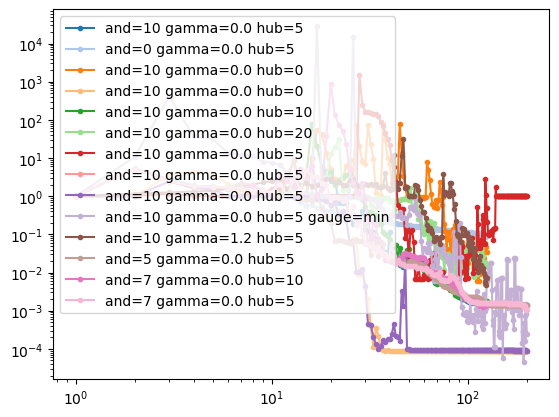

In [22]:
for i, file in enumerate(decm_test_files):
    label=file.split('decm')[1].replace('.pkl', '')
    if len(label)==0:
         label='and=10 gamma=0.0 hub=5'
    else:
        label=label.split('_')[1:]
        _label=''
        for i_l in range(len(label)//2):
            _label+=f'{label[2*i_l]}={label[2*i_l+1]} '
        label=_label.strip()
    with open(TEST_FOLDER+file, 'rb') as f:
        cacca=pickle.load(f)
    if len(cacca.sol.residuals)>cut:
        plt.plot(range(1, cut+1), cacca.sol.residuals[:cut], marker='o', label=label, color=colors_t20[i], markersize=3)
    else:
        plt.plot(range(1, len(cacca.sol.residuals)+1), cacca.sol.residuals, marker='o', label=label, color=colors_t20[i], markersize=3)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

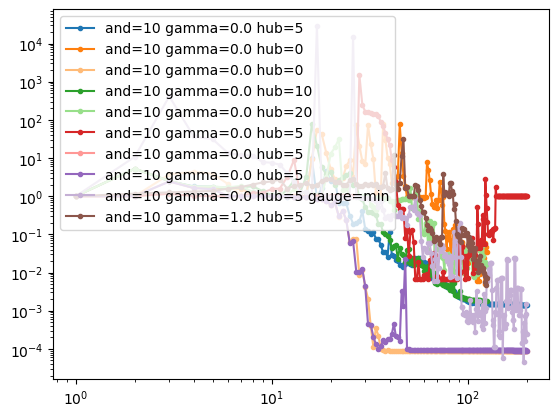

In [23]:
for i, file in enumerate(decm_test_files):
    label=file.split('decm')[1].replace('.pkl', '')
    if len(label)==0:
         label='and=10 gamma=0.0 hub=5'
    else:
        label=label.split('_')[1:]
        _label=''
        for i_l in range(len(label)//2):
            _label+=f'{label[2*i_l]}={label[2*i_l+1]} '
        label=_label.strip()
    if not label.startswith('and=10'):
        continue
    with open(TEST_FOLDER+file, 'rb') as f:
        cacca=pickle.load(f)
    if len(cacca.sol.residuals)>cut:
        plt.plot(range(1, cut+1), cacca.sol.residuals[:cut], marker='o', label=label, color=colors_t20[i], markersize=3)
    else:
        plt.plot(range(1, len(cacca.sol.residuals)+1), cacca.sol.residuals, marker='o', label=label, color=colors_t20[i], markersize=3)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

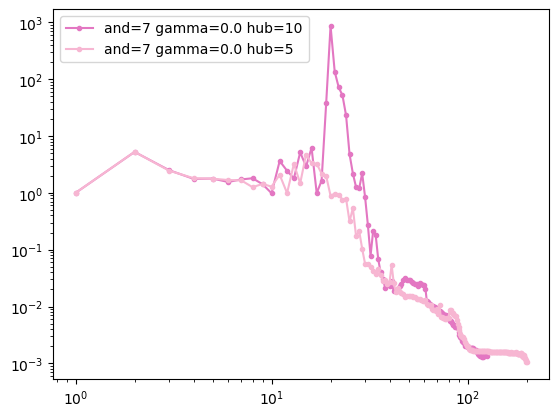

In [24]:
for i, file in enumerate(decm_test_files):
    label=file.split('decm')[1].replace('.pkl', '')
    if len(label)==0:
         label='and=10 gamma=0.0 hub=5'
    else:
        label=label.split('_')[1:]
        _label=''
        for i_l in range(len(label)//2):
            _label+=f'{label[2*i_l]}={label[2*i_l+1]} '
        label=_label.strip()
    if not label.startswith('and=7'):
        continue
    with open(TEST_FOLDER+file, 'rb') as f:
        cacca=pickle.load(f)
    if len(cacca.sol.residuals)>cut:
        plt.plot(range(1, cut+1), cacca.sol.residuals[:cut], marker='o', label=label, color=colors_t20[i], markersize=3)
    else:
        plt.plot(range(1, len(cacca.sol.residuals)+1), cacca.sol.residuals, marker='o', label=label, color=colors_t20[i], markersize=3)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

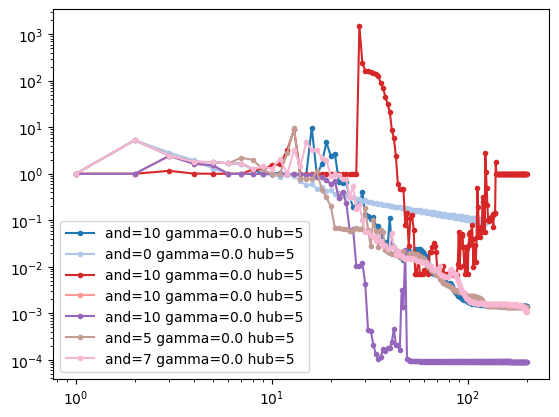

In [25]:
for i, file in enumerate(decm_test_files):
    label=file.split('decm')[1].replace('.pkl', '')
    if len(label)==0:
         label='and=10 gamma=0.0 hub=5'
    else:
        label=label.split('_')[1:]
        _label=''
        for i_l in range(len(label)//2):
            _label+=f'{label[2*i_l]}={label[2*i_l+1]} '
        label=_label.strip()
    if not label.endswith('gamma=0.0 hub=5'):
        continue
    with open(TEST_FOLDER+file, 'rb') as f:
        cacca=pickle.load(f)
    if len(cacca.sol.residuals)>cut:
        plt.plot(range(1, cut+1), cacca.sol.residuals[:cut], marker='o', label=label, color=colors_t20[i], markersize=3)
    else:
        plt.plot(range(1, len(cacca.sol.residuals)+1), cacca.sol.residuals, marker='o', label=label, color=colors_t20[i], markersize=3)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

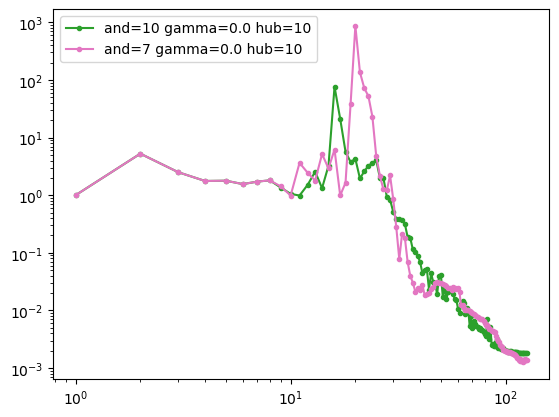

In [26]:
for i, file in enumerate(decm_test_files):
    label=file.split('decm')[1].replace('.pkl', '')
    if len(label)==0:
         label='and=10 gamma=0.0 hub=5'
    else:
        label=label.split('_')[1:]
        _label=''
        for i_l in range(len(label)//2):
            _label+=f'{label[2*i_l]}={label[2*i_l+1]} '
        label=_label.strip()
    if not label.endswith('hub=10'):
        continue
    with open(TEST_FOLDER+file, 'rb') as f:
        cacca=pickle.load(f)
    if len(cacca.sol.residuals)>cut:
        plt.plot(range(1, cut+1), cacca.sol.residuals[:cut], marker='o', label=label, color=colors_t20[i], markersize=3)
    else:
        plt.plot(range(1, len(cacca.sol.residuals)+1), cacca.sol.residuals, marker='o', label=label, color=colors_t20[i], markersize=3)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

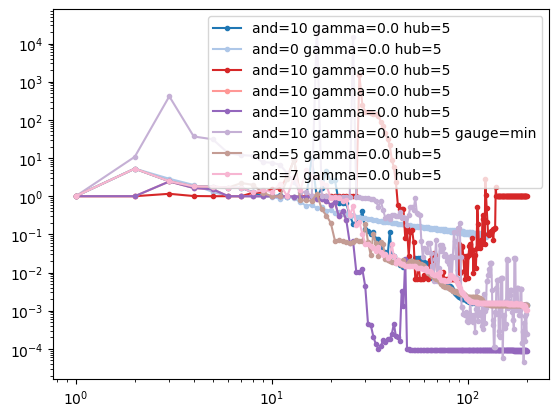

In [27]:
for i, file in enumerate(decm_test_files):
    label=file.split('decm')[1].replace('.pkl', '')
    if len(label)==0:
         label='and=10 gamma=0.0 hub=5'
    else:
        label=label.split('_')[1:]
        _label=''
        for i_l in range(len(label)//2):
            _label+=f'{label[2*i_l]}={label[2*i_l+1]} '
        label=_label.strip()
    if 'gamma=0.0 hub=5' not in label:
        continue
    with open(TEST_FOLDER+file, 'rb') as f:
        cacca=pickle.load(f)
    if len(cacca.sol.residuals)>cut:
        plt.plot(range(1, cut+1), cacca.sol.residuals[:cut], marker='o', label=label, color=colors_t20[i], markersize=3)
    else:
        plt.plot(range(1, len(cacca.sol.residuals)+1), cacca.sol.residuals, marker='o', label=label, color=colors_t20[i], markersize=3)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [28]:
cut2=1000

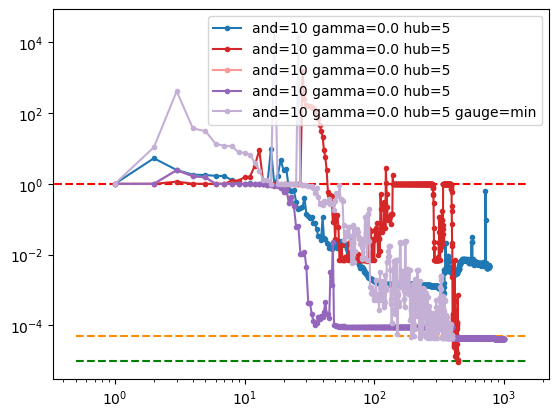

In [29]:
for i, file in enumerate(decm_test_files):
    label=file.split('decm')[1].replace('.pkl', '')
    if len(label)==0:
         label='and=10 gamma=0.0 hub=5'
    else:
        label=label.split('_')[1:]
        _label=''
        for i_l in range(len(label)//2):
            _label+=f'{label[2*i_l]}={label[2*i_l+1]} '
        label=_label.strip()
    if not label.startswith('and=10 gamma=0.0 hub=5'):
        continue
    with open(TEST_FOLDER+file, 'rb') as f:
        cacca=pickle.load(f)
    if len(cacca.sol.residuals)>cut2:
        plt.plot(range(1, cut2+1), cacca.sol.residuals[:cut2], marker='o', label=label, color=colors_t20[i], markersize=3)
    else:
        plt.plot(range(1, len(cacca.sol.residuals)+1), cacca.sol.residuals, marker='o', label=label, color=colors_t20[i], markersize=3)
plt.hlines([1e-5], 0.5, 1.5*cut2, linestyles='--', colors='green', zorder=1)
plt.hlines([5e-5], 0.5, 1.5*cut2, linestyles='--', colors='darkorange', zorder=1)
plt.hlines(1, -1, 1.5*cut2, linestyles='--', colors='red', zorder=1)
#plt.xlim(10**-8, 500)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

### Last runs

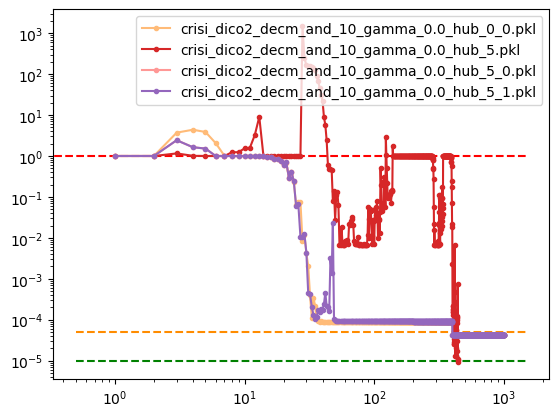

In [ ]:
for i, file in enumerate(decm_test_files):
    label=file.split('decm')[1].replace('.pkl', '')
    if len(label)==0:
         label='and=10 gamma=0.0 hub=5'
    else:
        label=label.split('_')[1:]
        _label=''
        for i_l in range(len(label)//2):
            _label+=f'{label[2*i_l]}={label[2*i_l+1]} '
        label=_label.strip()
    file_mtime = dt.date.fromtimestamp(os.path.getmtime(TEST_FOLDER+file))
    with open(TEST_FOLDER+file, 'rb') as f:
        cacca=pickle.load(f)
    if dt.date.today()-file_mtime > dt.timedelta(days=2) and not cacca.sol.converged:
        #print(f'[{dt.datetime.now():%Y-%m-%d %H:%M:%S}] The file {file} was not created/modified today. Skipping...')
        continue
    
    if len(cacca.sol.residuals)>cut2:
        plt.plot(range(1, cut2+1), cacca.sol.residuals[:cut2], marker='o', label=file, color=colors_t20[i], markersize=3)
    else:
        plt.plot(range(1, len(cacca.sol.residuals)+1), cacca.sol.residuals, marker='o', label=file, color=colors_t20[i], markersize=3)
plt.hlines([1e-5], 0.5, 1.5*cut2, linestyles='--', colors='green', zorder=1)
plt.hlines([5e-5], 0.5, 1.5*cut2, linestyles='--', colors='darkorange', zorder=1)
plt.hlines(1, -1, 1.5*cut2, linestyles='--', colors='red', zorder=1)
plt.xlim(1, 500)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [47]:
last_files=['crisi_dico2_decm_and_10_gamma_0.0_hub_0_0.pkl','crisi_dico2_decm_and_10_gamma_0.0_hub_5_1.pkl']
winning_file='crisi_dico2_decm_and_10_gamma_0.0_hub_5.pkl'

In [48]:
last_models=[]
for file in last_files:
    with open(TEST_FOLDER+file, 'rb') as f:
        last_models.append(pickle.load(f))
winning_model=pickle.load(open(TEST_FOLDER+winning_file, 'rb'))

In [54]:
[model.sol.mre for model in last_models], winning_model.sol.mre

([4.127410924980561e-05, 4.138443084961433e-05], 9.333978869248604e-06)

In [59]:
n_nodes=winning_model.N

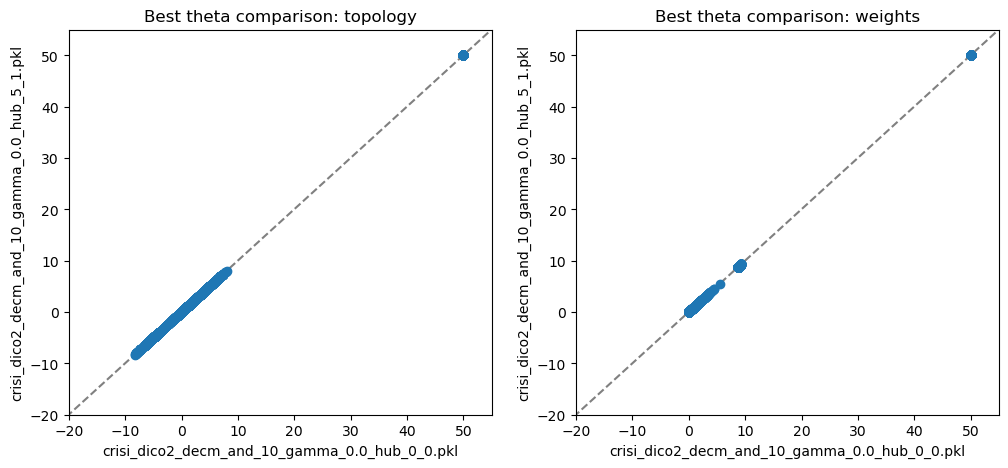

In [62]:
fig, axs=plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(last_models[0].sol.best_theta[:2*n_nodes], last_models[1].sol.best_theta[:2*n_nodes])
axs[0].plot([-100, 100], [-100, 100], linestyle='--', color='gray', zorder=0)
axs[0].set_title('Best theta comparison: topology')

axs[1].scatter(last_models[0].sol.best_theta[2*n_nodes:], last_models[1].sol.best_theta[2*n_nodes:])
axs[1].plot([-100, 100], [-100, 100], linestyle='--', color='gray', zorder=0)
axs[1].set_title('Best theta comparison: weights')

for i in range(len(axs)):
    axs[i].set_xlabel(last_files[0])
    axs[i].set_ylabel(last_files[1])
    axs[i].set_xlim(-20, 55)
    axs[i].set_ylim(-20, 55)
plt.show()

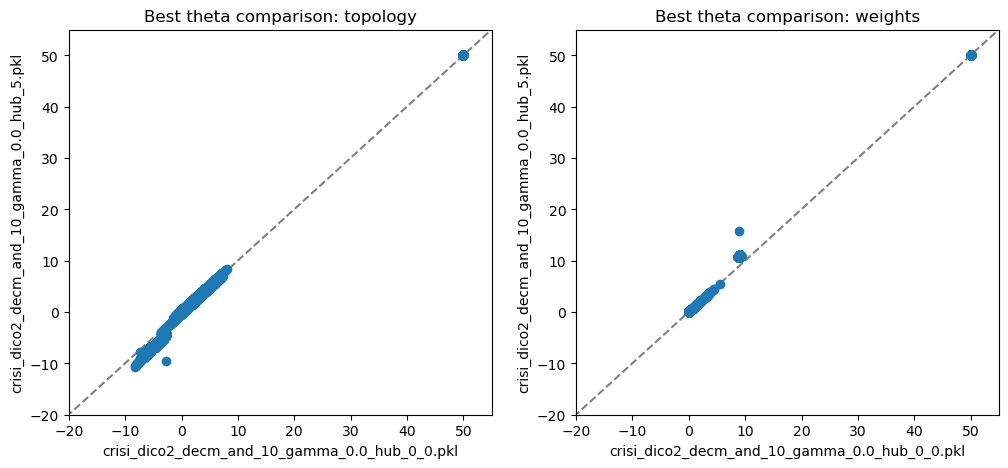

In [63]:
fig, axs=plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(last_models[0].sol.best_theta[:2*n_nodes], winning_model.sol.best_theta[:2*n_nodes])
axs[0].plot([-100, 100], [-100, 100], linestyle='--', color='gray', zorder=0)
axs[0].set_title('Best theta comparison: topology')

axs[1].scatter(last_models[0].sol.best_theta[2*n_nodes:], winning_model.sol.best_theta[2*n_nodes:])
axs[1].plot([-100, 100], [-100, 100], linestyle='--', color='gray', zorder=0)
axs[1].set_title('Best theta comparison: weights')

for i in range(len(axs)):
    axs[i].set_xlabel(last_files[0])
    axs[i].set_ylabel(winning_file)
    axs[i].set_xlim(-20, 55)
    axs[i].set_ylim(-20, 55)
plt.show()